✅ Found 48 images. Showing 3 samples with 462x462 Grid...



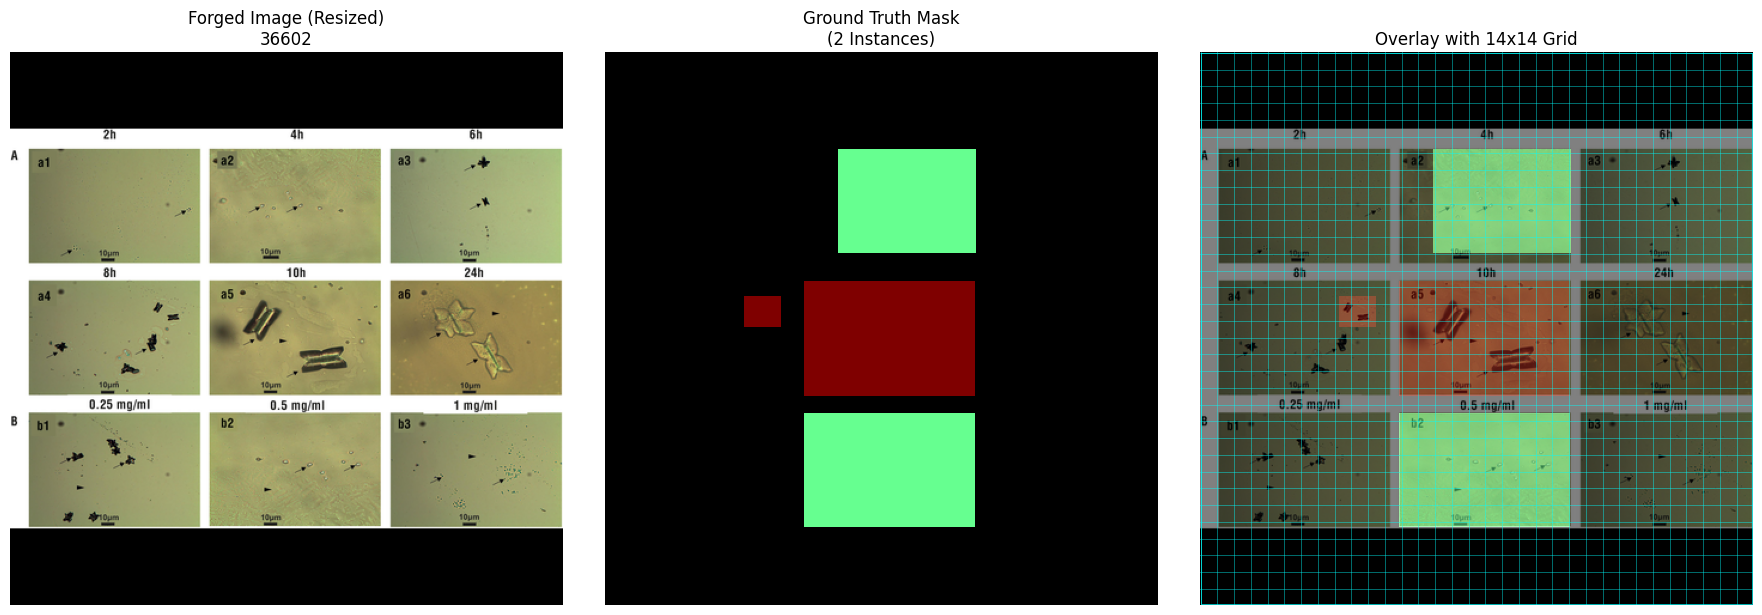

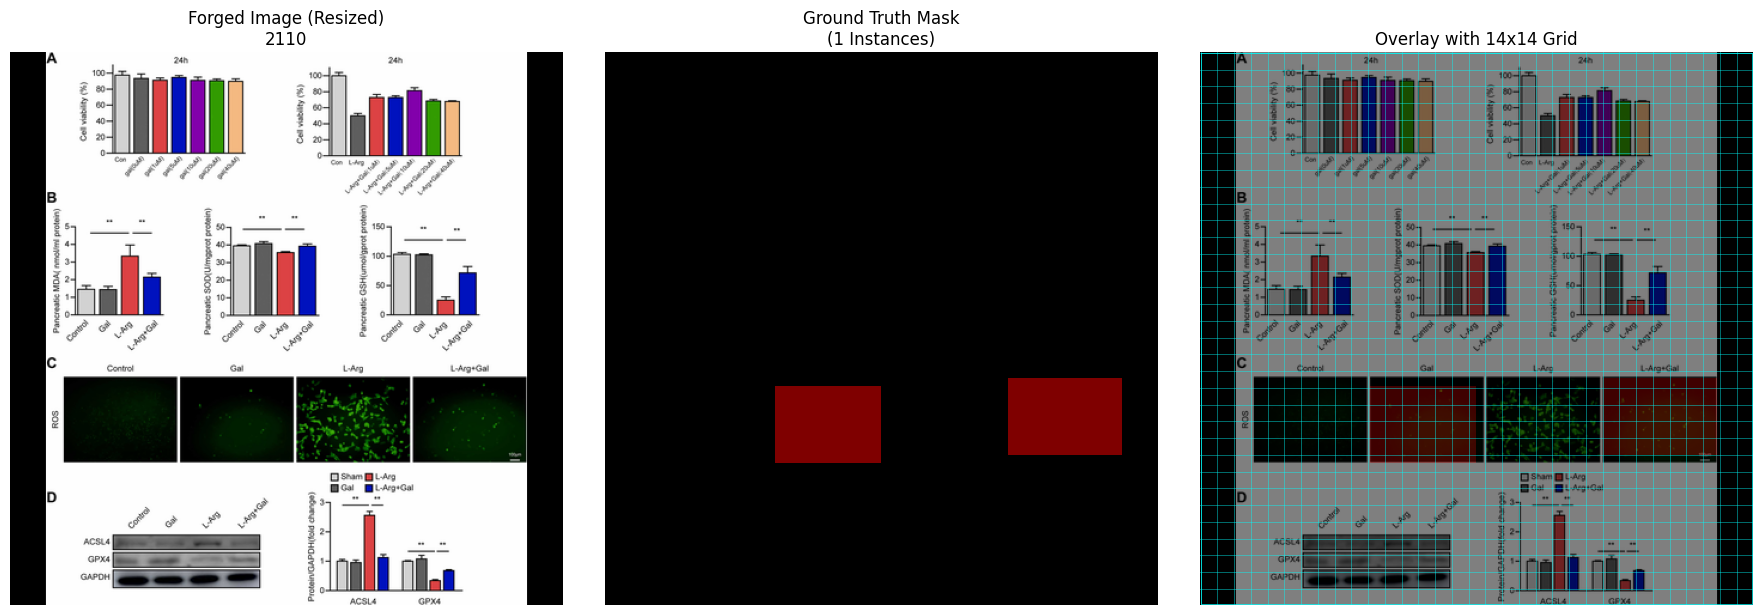

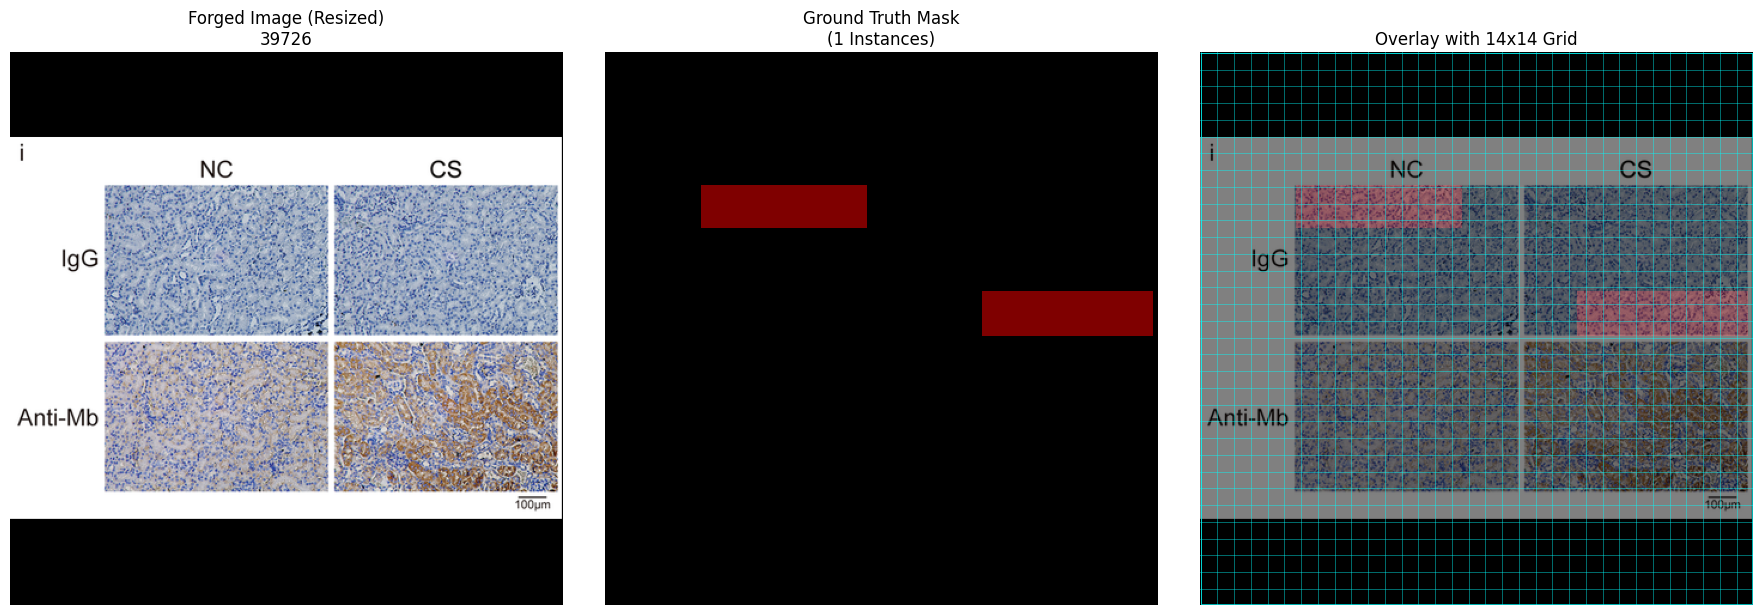

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from PIL import Image, ImageDraw
import random

# ==============================================================================
# HELPER: LETTERBOX RESIZE
# ==============================================================================
def resize_and_pad(image, target_size=462, is_mask=False):
    """
    Resizes image/mask to fit target_size x target_size while maintaining aspect ratio.
    Pads with black (or 0 for mask).
    """
    iw, ih = image.size
    w, h = target_size, target_size
    scale = min(w / iw, h / ih)
    nw = int(iw * scale)
    nh = int(ih * scale)

    # Use Nearest for masks to preserve class IDs, Lanczos for images for quality
    resample_method = Image.Resampling.NEAREST if is_mask else Image.Resampling.LANCZOS
    img_resized = image.resize((nw, nh), resample_method)

    # Create background (Black for RGB, 0 for Grayscale mask)
    mode = 'L' if is_mask else 'RGB'
    new_img = Image.new(mode, (target_size, target_size), 0)
    
    # Paste centered
    paste_x = (w - nw) // 2
    paste_y = (h - nh) // 2
    new_img.paste(img_resized, (paste_x, paste_y))
    
    return new_img

# ==============================================================================
# VISUALIZATION SCRIPT
# ==============================================================================

def visualize_generated_data(img_dir, mask_dir, num_samples=3):
    if not os.path.exists(img_dir):
        print(f"❌ Directory not found: {img_dir}")
        return

    files = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    if not files:
        print("❌ No images found.")
        return

    print(f"✅ Found {len(files)} images. Showing {num_samples} samples with 462x462 Grid...\n")
    
    selected_files = random.sample(files, min(len(files), num_samples))
    
    # Grid Configuration
    TARGET_SIZE = 462
    GRID_STEP = 14  # 33 cells * 14 px = 462

    for fname in selected_files:
        base_name = os.path.splitext(fname)[0]
        img_path = os.path.join(img_dir, fname)
        mask_path = os.path.join(mask_dir, f"{base_name}.npy")

        # 1. Load Image
        try:
            image_raw = Image.open(img_path).convert("RGB")
            W_orig, H_orig = image_raw.size
        except Exception as e:
            print(f"Error loading image {fname}: {e}")
            continue

        # 2. Load Mask Data
        if not os.path.exists(mask_path):
            print(f"Mask missing for {fname}")
            continue
            
        full_mask_np = None
        valid_instances = 0
        
        try:
            mask_data = np.load(mask_path, allow_pickle=True)
            full_mask_np = np.zeros((H_orig, W_orig), dtype=np.uint8)
            
            # --- Parse Mask (Same logic as before) ---
            if mask_data.ndim >= 2 and (np.issubdtype(mask_data.dtype, np.number) or mask_data.dtype == bool):
                if mask_data.ndim == 2:
                    if np.sum(mask_data) > 0:
                        full_mask_np[mask_data > 0] = 1
                        valid_instances = 1
                elif mask_data.ndim == 3:
                    num_instances = mask_data.shape[0]
                    for i in range(num_instances):
                        instance = mask_data[i]
                        if np.sum(instance) > 0:
                            if instance.shape != (H_orig, W_orig):
                                import cv2
                                instance = cv2.resize(instance.astype(np.uint8), (W_orig, H_orig), interpolation=cv2.INTER_NEAREST)
                            full_mask_np[instance > 0] = i + 1
                            valid_instances += 1
            else:
                print(f"⚠️ Unexpected data format: {mask_data.shape}. Skipping.")
                continue

        except Exception as e:
            print(f"Error processing mask {base_name}: {e}")
            continue

        # 3. Transform to 462x462 (Letterboxing)
        # Process Image
        final_image_pil = resize_and_pad(image_raw, TARGET_SIZE, is_mask=False)
        
        # Process Mask (Convert np to PIL -> Resize -> Back to np for plotting)
        mask_pil = Image.fromarray(full_mask_np)
        final_mask_pil = resize_and_pad(mask_pil, TARGET_SIZE, is_mask=True)
        final_mask_np = np.array(final_mask_pil)

        # 4. Display
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # --- Plot 1: The Resized Image ---
        axes[0].imshow(final_image_pil)
        axes[0].set_title(f"Forged Image (Resized)\n{base_name}")
        axes[0].axis('off')

        # --- Plot 2: The Resized Mask ---
        try:
            cmap = matplotlib.colormaps['jet'].copy()
        except AttributeError:
            cmap = plt.cm.get_cmap('jet').copy()
        cmap.set_under('black')
        
        safe_vmax = max(final_mask_np.max(), 1.0)
        axes[1].imshow(final_mask_np, cmap=cmap, vmin=0.1, vmax=safe_vmax, interpolation='nearest')
        axes[1].set_title(f"Ground Truth Mask\n({valid_instances} Instances)")
        axes[1].axis('off')

        # --- Plot 3: Overlay + GRID ---
        axes[2].imshow(final_image_pil)
        axes[2].imshow(final_mask_np, cmap=cmap, vmin=0.1, vmax=safe_vmax, alpha=0.5, interpolation='nearest')
        
        # Draw the 14x14 Grid on top using Matplotlib
        # Vertical lines
        for x in range(0, TARGET_SIZE, GRID_STEP):
            axes[2].axvline(x, color='cyan', linewidth=0.5, alpha=0.6)
        # Horizontal lines
        for y in range(0, TARGET_SIZE, GRID_STEP):
            axes[2].axhline(y, color='cyan', linewidth=0.5, alpha=0.6)
            
        # Draw Borders
        axes[2].plot([0, TARGET_SIZE-1, TARGET_SIZE-1, 0, 0], 
                     [0, 0, TARGET_SIZE-1, TARGET_SIZE-1, 0], color='cyan', linewidth=0.5)

        axes[2].set_title("Overlay with 14x14 Grid")
        axes[2].axis('off') # We turn off axis numbers, but keep the plot area for the grid

        plt.tight_layout()
        plt.show()

# ==============================================================================
# RUN
# ==============================================================================
# Update paths as needed
IMG_DIR = r"D:\projects\forgery\recodai-luc-scientific-image-forgery-detection\supplemental_images"
MASK_DIR = r"D:\projects\forgery\recodai-luc-scientific-image-forgery-detection\supplemental_masks"

visualize_generated_data(IMG_DIR, MASK_DIR, num_samples=3)

In [1]:
import torch

# Replace this with the path to the checkpoint you want to check
# Example locations based on your config:
# 1. Pretrained input: "/kaggle/input/sci-forge-dino-sim/pytorch/default/1/best_checkpoint.pth"
# 2. Fine-tuned output: "/kaggle/working/finetune_checkpoints/finetune_best.pth"

checkpoint_path = r"D:\projects\forgery\best_checkpoint.pth"

try:
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    print(f"📄 File: {checkpoint_path}")
    print(f"🏆 Best OF1 Score: {checkpoint.get('best_of1', 'Not found in checkpoint')}")
    print(f"🔄 Epoch: {checkpoint.get('epoch', 'Not found')}")
    
except FileNotFoundError:
    print(f"❌ File not found at: {checkpoint_path}")
except Exception as e:
    print(f"❌ Error loading checkpoint: {e}")

📄 File: D:\projects\forgery\best_checkpoint.pth
🏆 Best OF1 Score: 0.37274225220028506
🔄 Epoch: 39
